In [22]:
import pandas as pd
import numpy as np


In [24]:
df=pd.read_csv("powerplant_data.csv")

In [26]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [28]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [30]:
#splitting data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)


In [31]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [33]:
#coverting into tensors

import torch
import torch.nn as nn


X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [35]:
#dataset and dataloader

#tensor dataset object
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)


In [38]:
#dataloader
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [40]:
X_train.shape[1]

4

In [41]:
#define ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
        #1st hidden
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
        #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

        #output layer
            nn.Linear(6,1),
   
    )

    def forward(self,x):
        return self.model(x)

In [42]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [43]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 206715.64322916666 & val loss = 205912.1703125
epoch 2/100 ==> train loss = 203772.5328125 & val loss = 199765.64114583333
epoch 3/100 ==> train loss = 192193.9251953125 & val loss = 182395.93828125
epoch 4/100 ==> train loss = 168606.0328125 & val loss = 153103.65260416668
epoch 5/100 ==> train loss = 134863.88245442708 & val loss = 116467.50559895833
epoch 6/100 ==> train loss = 97572.15009765625 & val loss = 80376.882421875
epoch 7/100 ==> train loss = 64999.115071614586 & val loss = 52579.03177083333
epoch 8/100 ==> train loss = 42735.93924967448 & val loss = 35516.369791666664
epoch 9/100 ==> train loss = 30004.293131510418 & val loss = 26258.166145833333
epoch 10/100 ==> train loss = 23167.882727050783 & val loss = 21028.531103515626
epoch 11/100 ==> train loss = 19088.68760579427 & val loss = 17588.344498697916
epoch 12/100 ==> train loss = 16144.838041178386 & val loss = 14918.62294921875
epoch 13/100 ==> train loss = 13674.554728190104 & val loss =

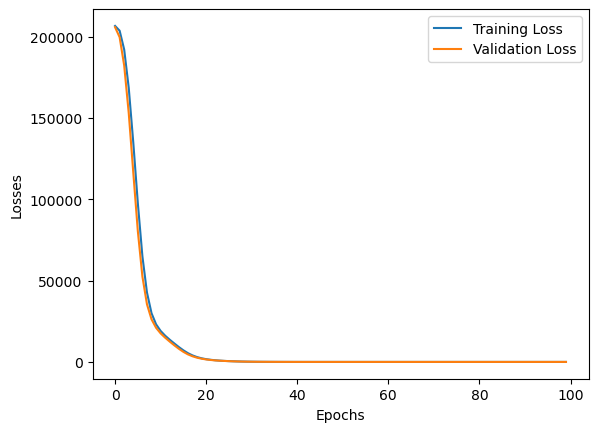

In [44]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [46]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [47]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 21.218814849853516
Testing MSE: 19.690998077392578


In [48]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9311850474339927


In [49]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.401459,433.27
1,437.188385,438.16
2,461.149445,458.42
3,476.119751,480.82
4,435.394012,441.41
...,...,...
1909,451.423553,456.70
1910,431.838257,438.04
1911,467.598419,467.80
1912,431.308777,437.14
